<a href="https://colab.research.google.com/github/KaikyDegasperi/Apresentacao/blob/master/MetricasEFuncoesDePerda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sobre o Conjunto de Dados

- **Idade**: Idade do paciente.
- **Sexo**: Gênero do paciente.
- **Tipo de Dor no Peito**: Atributo categórico que indica o tipo de dor no peito experimentada pelo paciente. Possui quatro valores possíveis.
- **Pressão Arterial em Repouso**: Pressão arterial em repouso do paciente.
- **Colesterol Sérico**: Nível de colesterol sérico em mg/dl do paciente.
- **Açúcar no Sangue em Jejum**: Indica se o açúcar no sangue em jejum do paciente é maior que 120 mg/dl.
- **Resultados do Eletrocardiograma em Repouso**: Atributo categórico que representa os resultados do eletrocardiograma em repouso. Possui três valores possíveis.
- **Frequência Cardíaca Máxima Alcançada**: A frequência cardíaca máxima alcançada pelo paciente.
- **Angina Induzida por Exercício**: Indica se o paciente experimentou angina (dor no peito) induzida por exercício.
- **Depressão de ST Induzida por Exercício em Relação ao Repouso**: ST depression induced by exercise relative to rest.
- **Inclinação do Segmento ST do Exercício de Pico**: A inclinação do segmento ST do exercício de pico.
- **Número de Vasos Sanguíneos Principais**: Representa o número de principais vasos sanguíneos coloridos por fluoroscopia (variando de 0 a 3).
- **Thal**: Atributo categórico que indica o tipo de talassemia do paciente. Possui três valores possíveis: 0 para normal, 1 para defeito fixo e 2 para defeito reversível.
- **Alvo**: A coluna alvo serve como a variável de resultado e indica a presença de doença cardíaca no paciente. Um valor de 0 significa a ausência de doença cardíaca, enquanto um valor de 1 indica a presença de doença cardíaca.


Dados de treino:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dados de teste:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       1

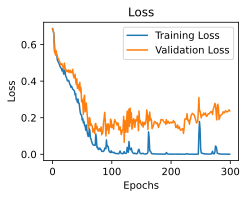

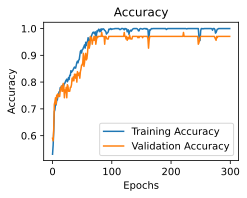

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Carregar os dados de treino
train_data = pd.read_csv('train_heart.csv')

# Carregar os dados de teste
test_data = pd.read_csv('test_heart.csv')

# Visualizando as primeiras linhas dos dados de treino
print("Dados de treino:")
print(train_data.head())

# Visualizando as primeiras linhas dos dados de teste
print("\nDados de teste:")
print(test_data.head())

# Separando as features e o target dos dados de treino
X_train = train_data.drop('target', axis=1)
y_train = train_data['target']

# Separando as features e o target dos dados de teste
X_test = test_data.drop('target', axis=1)
y_test = test_data['target']

# Dividindo o conjunto de dados em conjuntos de treinamento e teste
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Redimensionando os dados para o formato esperado pela LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Definindo o modelo LSTM
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))

# Compilando o modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando o modelo
history = model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Avaliando o modelo
loss, accuracy = model.evaluate(X_test, y_test)
print("Acurácia do modelo:", accuracy)

# Plotando a curva de perda
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotando a curva de acurácia
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


10/10 [==============================] - 0s 18ms/step


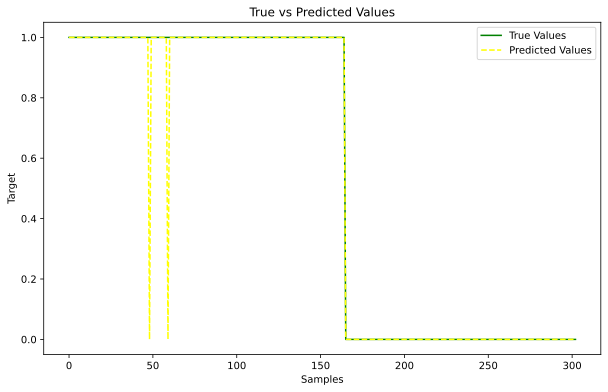

In [14]:
# Fazendo previsões no conjunto de teste
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)  # Convertendo as probabilidades em valores binários

# Plotando as previsões em comparação com os valores verdadeiros
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='green')
plt.plot(y_pred, label='Predicted Values', color='yellow', linestyle='--')
plt.title('True vs Predicted Values')
plt.xlabel('Samples')
plt.ylabel('Target')
plt.legend()
plt.show()


# Matriz de Dispersão

A matriz de dispersão é uma ferramenta visual poderosa usada na análise exploratória de dados para examinar a relação entre múltiplas variáveis ​​de forma simultânea. Também conhecida como scatterplot matrix em inglês, essa matriz mostra todos os pares de variáveis em um conjunto de dados em um conjunto de gráficos de dispersão.

## Como Funciona

Cada célula da matriz exibe um gráfico de dispersão que compara duas variáveis. Na diagonal principal, os gráficos de dispersão mostram a distribuição univariada de cada variável. Fora da diagonal principal, os gráficos de dispersão mostram a relação entre duas variáveis.

## Quando Usar

- **Exploração de Relações:** A matriz de dispersão é útil para identificar padrões e relações entre variáveis em um conjunto de dados.
- **Identificação de Correlações:** Ela ajuda a visualizar correlações lineares e não lineares entre pares de variáveis.
- **Detecção de Outliers:** Pode ser usada para identificar valores atípicos ou outliers em diferentes combinações de variáveis.

## Limitações

- **Dificuldade com Conjuntos de Dados Grandes:** Em conjuntos de dados com muitas variáveis, a matriz de dispersão pode se tornar difícil de interpretar devido ao grande número de gráficos.
- **Apenas para Relações Bivariadas:** A matriz de dispersão é mais eficaz para analisar relações entre pares de variáveis e pode não capturar relações complexas envolvendo mais de duas variáveis simultaneamente.

## Exemplo de Uso

Vamos considerar um conjunto de dados com variáveis como altura, peso e idade. Usando uma matriz de dispersão, podemos visualizar as relações entre essas variáveis e identificar possíveis padrões ou tendências.

A matriz de dispersão é uma ferramenta valiosa na análise exploratória de dados, proporcionando insights visuais sobre as relações entre as variáveis e auxiliando na identificação de padrões e tendências.


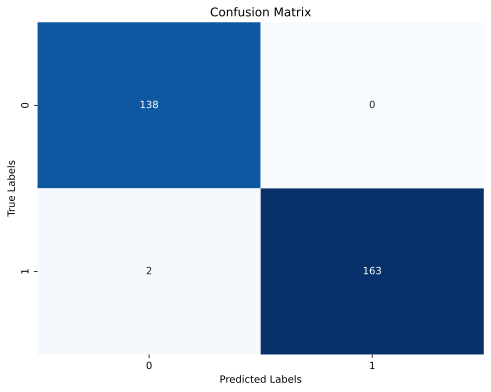

In [19]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Acurácia

A acurácia é uma métrica comum usada para avaliar a performance de um modelo de classificação. Ela representa a proporção de predições corretas feitas pelo modelo em relação ao total de predições feitas.

## Fórmula

A fórmula para calcular a acurácia é:

$\text{Acurácia} = \frac{\text{Número de predições corretas}}{\text{Total de predições}} $

## Interpretação

- Uma alta acurácia indica que o modelo está fazendo a maioria das predições corretamente.
- No entanto, a acurácia pode ser enganosa em conjuntos de dados desbalanceados, onde uma classe é muito mais prevalente do que outra.

A acurácia é uma métrica útil para avaliar modelos de classificação, mas é importante considerar outras métricas, especialmente em situações de desbalanceamento de classes.


In [20]:
# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

Acurácia: 0.9933993399339934




## Recall

### Definição
Recall, também conhecido como sensibilidade ou taxa de verdadeiros positivos, mede a proporção de casos positivos reais que foram corretamente identificados pelo modelo.

### Fórmula
Recall = TP / (TP + FN)

### Interpretação
- Um recall alto indica que o modelo é capaz de identificar corretamente a maioria dos casos positivos, minimizando os falsos negativos.
- No entanto, um recall alto pode vir com o custo de aumentar os falsos positivos.



In [21]:
# Calcular o recall
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9878787878787879


# Precisão

- A precisão é uma métrica de avaliação que mede a proporção de exemplos positivos classificados corretamente pelo modelo em relação a todos os exemplos positivos previstos.
- Em outras palavras, a precisão mede a qualidade das previsões positivas do modelo.
- A fórmula para calcular a precisão é:

$
\text{Precisão} = \frac{TP}{TP + FP}
$

onde:
  - \(TP\) é o número de verdadeiros positivos (exemplos positivos classificados corretamente)
  - \(FP\) é o número de falsos positivos (exemplos negativos classificados incorretamente como positivos)

- Uma precisão mais alta indica que o modelo tem uma proporção maior de previsões positivas corretas, enquanto uma precisão mais baixa indica que o modelo faz mais previsões positivas erradas.



In [25]:
precision = precision_score(y_test,y_pred)

print('A precisão é', precision)

A precisão é 1.0


# F1 Score

O F1 Score é uma métrica de avaliação comumente usada em problemas de classificação binária para medir a precisão do modelo. É a média harmônica da precisão e do recall, fornecendo uma única pontuação que indica o equilíbrio entre essas duas métricas.

## Fórmula

O F1 Score é calculado pela seguinte fórmula:

$ F1 = 2 \times \frac{\text{Precisão} \times \text{Recall}}{\text{Precisão} + \text{Recall}} $

## Interpretação

- O F1 Score varia entre 0 e 1.
- Um F1 Score mais alto indica um melhor equilíbrio entre precisão e recall.
- Um F1 Score de 1 indica um modelo perfeito que alcança precisão e recall máximos.


In [23]:
# Calcular o F1 Score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9939024390243903
